# Analysis for documentation

In [1]:
import sys
sys.path.insert(0, '/home/neam/01_SST_VAR')
import geostats as gs

from glob import glob
import xarray as xr
import numpy as np
import intake
from dask.diagnostics import ProgressBar
import healpy as hp
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import pandas as pd
import cartopy.feature as cfeature
import cartopy.crs as ccrs
import cmocean.cm as cmo

/perm/neam/conda/envs/science4/lib/python3.13/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)


In [2]:
def bias_time(ds, time_slice, dim='time',log=False):
    '''
    Remove the time mean from the dataset, where the time mean is computed over a specified time slice.
    '''
    ds_time_slice = ds.sel({dim: slice(*time_slice)})
    if log:
        print(ds_time_slice)
    ds_time_mean = ds_time_slice.mean(dim)
    # ds_time_mean = ds.sel({dim: slice(*time_slice)}).mean(dim)
    return ds - ds_time_mean

# Open local catalog

In [3]:
import intake
cat = intake.open_catalog('/home/neam/code/intake_atos/eerie.yaml')

## Compute GSAT

In [4]:
# ERA5
era5 = cat['obs']['ERA5']['monthly'].to_dask()
# Berkeley Earth
berk = cat['AQUA']['datasets']['BERKELEY-EARTH']['monthly'](chunks={}).to_dask()

/perm/neam/conda/envs/science4/lib/python3.13/site-packages/intake_xarray/base.py:21: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  'dims': dict(self._ds.dims),
/perm/neam/conda/envs/science4/lib/python3.13/site-packages/intake_xarray/base.py:21: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  'dims': dict(self._ds.dims),


In [5]:
gsat_dict = {}

In [6]:
# Berkeley Earth
gsat_berk = gs.area_mean(berk['2t'])
with ProgressBar():
    gsat_berk.load()
gsat_dict['BERKELEY-EARTH'] = gsat_berk

# ERA5
gsat_era5 = gs.area_mean(era5['t2m'])
with ProgressBar():
    gsat_era5.load()
gsat_dict['ERA5'] = gsat_era5

Computing grid-box area


/perm/neam/conda/envs/science4/lib/python3.13/site-packages/iris/analysis/cartography.py:435: IrisDefaultingWarning: Using DEFAULT_SPHERICAL_EARTH_RADIUS.
  warnings.warn(


[########################################] | 100% Completed | 1.83 sms
Computing grid-box area
[#                                       ] | 3% Completed | 104.88 ms

/perm/neam/conda/envs/science4/lib/python3.13/site-packages/iris/analysis/cartography.py:435: IrisDefaultingWarning: Using DEFAULT_SPHERICAL_EARTH_RADIUS.
  warnings.warn(


[########################################] | 100% Completed | 4.53 ss


In [7]:
# climateDT models - switch for polytope
for model in ['IFS-NEMO','IFS-FESOM','ICON']:
    print('Processing model:', model)
    gsat_dict[model] = xr.concat(
        [
            cat['destine']['phase2'][model]['hist-1990']['standard']['monthly'](chunks={}).to_dask()['avg_2t'].mean('value'),
            cat['destine']['phase2'][model]['ssp370']['standard']['monthly'](chunks={}).to_dask()['avg_2t'].mean('value')
        ],'time'
    ).load()

Processing model: IFS-NEMO


/perm/neam/conda/envs/science4/lib/python3.13/site-packages/intake_xarray/base.py:21: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  'dims': dict(self._ds.dims),
/perm/neam/conda/envs/science4/lib/python3.13/site-packages/intake_xarray/base.py:21: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  'dims': dict(self._ds.dims),


Processing model: IFS-FESOM


/perm/neam/conda/envs/science4/lib/python3.13/site-packages/intake_xarray/base.py:21: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  'dims': dict(self._ds.dims),
/perm/neam/conda/envs/science4/lib/python3.13/site-packages/intake_xarray/base.py:21: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  'dims': dict(self._ds.dims),


Processing model: ICON


/perm/neam/conda/envs/science4/lib/python3.13/site-packages/intake_xarray/base.py:21: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  'dims': dict(self._ds.dims),
/perm/neam/conda/envs/science4/lib/python3.13/site-packages/intake_xarray/base.py:21: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  'dims': dict(self._ds.dims),


In [8]:
# CMIP models - switch for polytope using CDS directly
cds_cmip_hist = xr.open_zarr('/ec/fws5/lb/project/eerie/data/CDS/atlas/historical.zarr')
cds_cmip_370 = xr.open_zarr('/ec/fws5/lb/project/eerie/data/CDS/atlas/ssp370.zarr')

area_cmip = gs.get_area(cds_cmip_370['t'].isel(member=0))
area_cmip = area_cmip.drop([d for d in area_cmip.coords if not d in area_cmip.dims])

cds_cmip_hist_gsat  = cds_cmip_hist['t'].weighted(area_cmip).mean(['lat','lon'])
cds_cmip_370_gsat  = cds_cmip_370['t'].weighted(area_cmip).mean(['lat','lon'])

models = np.intersect1d(
    cds_cmip_hist_gsat['gcm_model'].values,
    cds_cmip_370_gsat['gcm_model'].values
)
cds_cmip_gsat_hist_370 = xr.concat(
    [
        cds_cmip_hist_gsat.swap_dims({'member':'gcm_model'}).sel(gcm_model=models),
        cds_cmip_370_gsat.swap_dims({'member':'gcm_model'}).sel(gcm_model=models)
    ],'time'
)

with ProgressBar():
    cds_cmip_gsat_hist_370.load()

Computing grid-box area


/perm/neam/conda/envs/science4/lib/python3.13/site-packages/iris/analysis/cartography.py:435: IrisDefaultingWarning: Using DEFAULT_SPHERICAL_EARTH_RADIUS.
  warnings.warn(
/etc/ecmwf/ssd/ssd1/jupyterhub/neam-jupyterhub/tmpdirs/neam.24872391/ipykernel_153183/2692384566.py:6: DeprecationWarning: dropping variables using `drop` is deprecated; use drop_vars.
  area_cmip = area_cmip.drop([d for d in area_cmip.coords if not d in area_cmip.dims])


[########################################] | 100% Completed | 12.35 s


# Plots

## Plot GSAT

Text(0.5, 1.0, 'Global Surface Air Temperature Anomaly relative to 1990-2014')

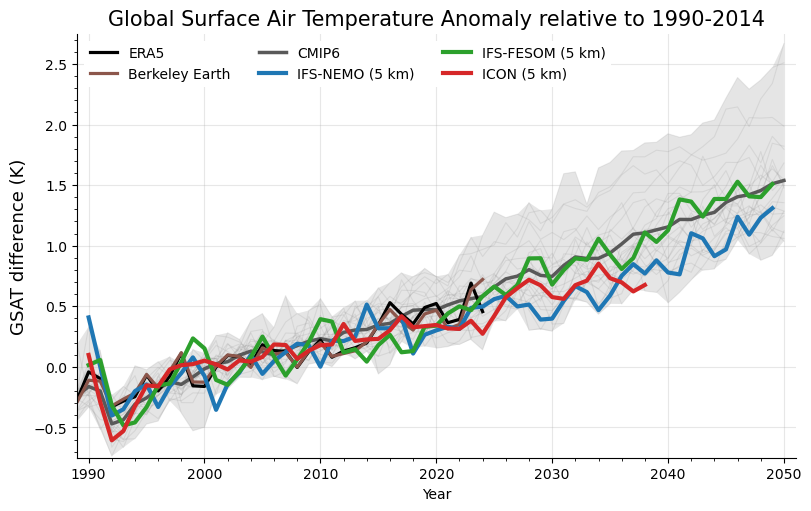

In [9]:
fig, ax = plt.subplots(constrained_layout=True, figsize=(8,5))

# --- CMIP spaghetti ---
cmip = bias_time(
    (cds_cmip_gsat_hist_370
         .resample(time='1YE').mean()
         .sel(time=slice('1950','2050')) 
       ).groupby('time.year').mean(),
    (1990,2014),
    'year'
)

cmip.plot.line(
    hue='gcm_model',
    add_legend=False,
    alpha=0.15,         # lighter
    color='grey',
    lw=0.8,             # thinner
    ax=ax
)

# --- CMIP envelope ---
t = cmip
ax.fill_between(
    t['year'],
    t.min('gcm_model'),
    t.max('gcm_model'),
    alpha=0.2,
    color='grey',
    lw=0
)

# --- CMIP mean ---
t.mean('gcm_model').plot.line(
    add_legend=False,
    lw=2.5,
    color='0.35',
    ax=ax,
    label='CMIP6'
)

# --- ERA5 ---
bias_time(
    (
        gsat_era5.resample(time='1YE').mean()
        - 273.15
    ).groupby('time.year').mean(),
    (1990,2014),
    'year'
).plot.line(
    color='k',
    label='ERA5',
    lw=2.3,
    ax=ax
)
# --- Berkeley Earth ---
bias_time(
    (
        gsat_berk.resample(time='1YE').mean()
    ).groupby('time.year').mean(),
    (1990,2014),
    'year'
).plot.line(
    color='tab:brown',
    label='Berkeley Earth',
    lw=2.3,
    ax=ax
)


# Production runs
colors = ['tab:blue', 'tab:green', 'tab:red']
labels = [
    'IFS-NEMO (5 km)',
    'IFS-FESOM (5 km)',
    'ICON (5 km)'
]
keys = [
    'IFS-NEMO',
    'IFS-FESOM',
    'ICON'
]

for key, col, lab in zip(keys, colors, labels):
    bias_time(
        (
            gsat_dict[key].resample(time='1YE').mean()
            - 273.15
        ).groupby('time.year').mean(),
        (1990,2014),
        'year'
    ).plot.line(
    color=col,
    lw=3,
    label=lab,
    ax=ax
)

# --- Styling ---
handles, labels = ax.get_legend_handles_labels()

# Example: reorder the first, third, and second items
order = [1, 2, 0, 3, 4, 5]

leg = ax.legend([handles[i] for i in order],
          [labels[i] for i in order],
          ncols=3, 
          framealpha=1
          )

leg.get_frame().set_edgecolor('none')
leg.get_frame().set_linewidth(0)

ax.set_xlim(1989,2051)
ax.set_ylim(-0.75,2.75)

ax.grid(True, alpha=0.3)
ax.minorticks_on()

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.set_xlabel('Year')
ax.set_ylabel('GSAT difference (K)', fontsize=13)
ax.set_title('Global Surface Air Temperature Anomaly relative to 1990-2014', fontsize=15)

# fig.savefig('plots/climatedt_gsat_anomaly_timeseries.pdf')
# fig.savefig('plots/climatedt_gsat_anomaly_timeseries.png', dpi=300)

Text(0.5, 1.0, 'Global Surface Air Temperature')

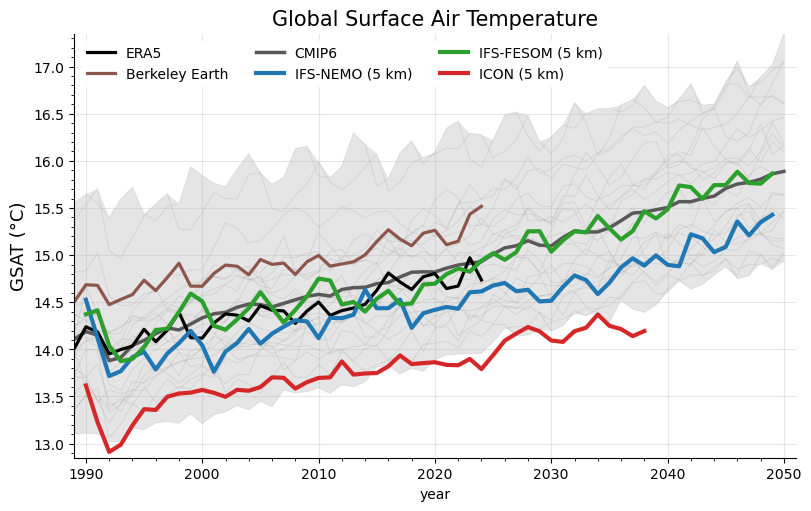

In [10]:
fig, ax = plt.subplots(constrained_layout=True, figsize=(8,5))

# --- CMIP spaghetti ---
cmip = (cds_cmip_gsat_hist_370
         .resample(time='1YE').mean()
         .sel(time=slice('1950','2050')) 
        # + 273.15
       )

cmip.groupby('time.year').mean().plot.line(
    hue='gcm_model',
    add_legend=False,
    alpha=0.15,         # lighter
    color='grey',
    lw=0.8,             # thinner
    ax=ax
)

# --- CMIP envelope ---
t = cmip
ax.fill_between(
    t['time.year'],
    t.min('gcm_model'),
    t.max('gcm_model'),
    alpha=0.2,
    color='grey',
    lw=0
)

# --- CMIP mean ---
t.mean('gcm_model').groupby('time.year').mean().plot.line(
    add_legend=False,
    lw=2.5,
    color='0.35',
    ax=ax,
    label='CMIP6'
)

# --- ERA5 ---
(
    gsat_era5.resample(time='1YE').mean()
    - 273.15
).groupby('time.year').mean().plot.line(
    color='k',
    label='ERA5',
    lw=2.3,
    ax=ax
)
# --- Berkeley Earth ---
(
    gsat_berk.resample(time='1YE').mean()
).groupby('time.year').mean().plot.line(
    color='tab:brown',
    label='Berkeley Earth',
    lw=2.3,
    ax=ax
)


# Production runs
colors = ['tab:blue', 'tab:green', 'tab:red']
labels = [
    'IFS-NEMO (5 km)',
    'IFS-FESOM (5 km)',
    'ICON (5 km)'
]
keys = [
    'IFS-NEMO',
    'IFS-FESOM',
    'ICON'
]

for key, col, lab in zip(keys, colors, labels):
    (
        gsat_dict[key].resample(time='1YE').mean()
        - 273.15
    ).groupby('time.year').mean().plot.line(
        color=col,
        lw=3,
        label=lab,
        ax=ax
    )

# --- Styling ---
handles, labels = ax.get_legend_handles_labels()

# Example: reorder the first, third, and second items
order = [1, 2, 0, 3, 4, 5 ]

leg = ax.legend([handles[i] for i in order],
          [labels[i] for i in order],
          ncols=3, 
          framealpha=1
          )

leg.get_frame().set_edgecolor('none')
leg.get_frame().set_linewidth(0)

ax.set_xlim(1989,2051)
ax.set_ylim(286 - 273.15, 290.5 - 273.15)

ax.grid(True, alpha=0.3)
ax.minorticks_on()

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.set_ylabel('GSAT (°C)', fontsize=13)
ax.set_title('Global Surface Air Temperature', fontsize=15)

# fig.savefig('plots/climatedt_gsat_timeseries.pdf')
# fig.savefig('plots/climatedt_gsat_timeseries.png', dpi=300)

In [ ]:
print('Done')